# Air Quality Forecasting

This notebook compares deep learning models for air-quality time-series forecasting using the UCI Air Quality dataset.


# =============================================================================
# Step 0: Import libraries
# =============================================================================


In [ ]:
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.layers import Dense, Conv1D, LSTM, Lambda, Reshape, RNN, LSTMCell

import warnings
warnings.filterwarnings('ignore')


In [ ]:
plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False


In [ ]:
print(tf.__version__)


2.18.0


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)


# =============================================================================
# Step 1: Load the dataset
# =============================================================================


## Dataset Setup

This notebook expects preprocessed UCI Air Quality train, validation, and test CSV files to be available before running the data-loading cell.

For Google Colab, upload these files to `/content/`:

- `air_quality_train.csv`
- `air_quality_val.csv`
- `air_quality_test.csv`

Later, this notebook can be extended to download the original UCI Air Quality dataset and generate these splits automatically.


In [ ]:
train_df = pd.read_csv('/content/air_quality_train.csv', index_col=0)
val_df = pd.read_csv('/content/air_quality_val.csv', index_col=0)
test_df = pd.read_csv('/content/air_quality_test.csv', index_col=0)

print(train_df.shape, val_df.shape, test_df.shape)


(6549, 7) (1872, 7) (936, 7)


In [ ]:
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()


# =============================================================================
# Step 2: Visualize the time series
# =============================================================================
## Target column: C6H6(GT)


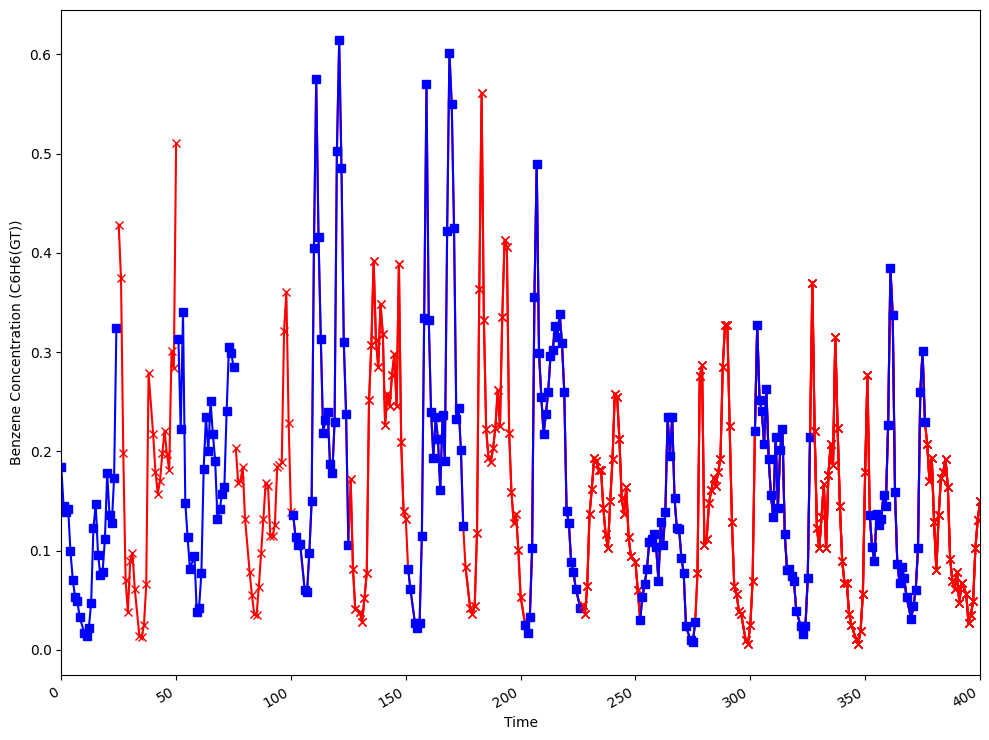

In [ ]:
fig, ax = plt.subplots()
for n in range(0, 17, 2):
    start = 24 * n
    stop = 24 * (n + 1)
    ax.plot(train_df['C6H6(GT)'][start:stop], marker='s', color='blue', label='input')
    ax.plot(train_df['C6H6(GT)'][stop:2 * stop], marker='x', color='red', label='label')
ax.set_xlabel('Time')
ax.set_ylabel('Benzene Concentration (C6H6(GT))')
plt.xlim(0, 400)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


# =============================================================================
# Step 3: Implementing the `DataWindow` class
# =============================================================================


In [ ]:
class DataWindow():
    def __init__(self, input_width, label_width, shift, train_df=train_df, val_df=val_df, test_df=test_df, label_columns=None):
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.label_columns = label_columns

        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def split_to_inputs_labels(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        if self.label_columns is not None:
            labels = tf.stack([labels[:, :, self.column_indices[name]] for name in self.label_columns], axis=-1)
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels

    def plot(self, model=None, plot_col='C6H6(GT)', max_subplots=3):
        inputs, labels = self.sample_batch
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        max_n = min(max_subplots, len(inputs))

        for n in range(max_n):
            plt.subplot(3, 1, n + 1)
            plt.ylabel(f'{plot_col} [scaled]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index], label='Inputs', marker='.', zorder=-10)

            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            plt.scatter(self.label_indices, labels[n, :, label_col_index], edgecolors='k', marker='s', label='Labels', c='green', s=64)
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index], marker='X', edgecolors='k', label='Predictions', c='red', s=64)

            if n == 0:
                plt.legend()

        plt.xlabel('Time (h)')

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.preprocessing.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,
            batch_size=32
        )
        ds = ds.map(self.split_to_inputs_labels)
        return ds

    @property
    def train(self):
        return self.make_dataset(self.train_df)

    @property
    def val(self):
        return self.make_dataset(self.val_df)

    @property
    def test(self):
        return self.make_dataset(self.test_df)

    @property
    def sample_batch(self):
        result = getattr(self, '_sample_batch', None)
        if result is None:
            result = next(iter(self.train))
            self._sample_batch = result
        return result


# =============================================================================
# Step 4: Applying baseline models
# =============================================================================
## Single-step baseline model


In [ ]:
single_step_window = DataWindow(input_width=1, label_width=1, shift=1, label_columns=['C6H6(GT)'])
wide_window = DataWindow(input_width=24, label_width=24, shift=1, label_columns=['C6H6(GT)'])


In [ ]:
class Baseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        if self.label_index is None:
            return inputs

        elif isinstance(self.label_index, list):
            tensors = []
            for index in self.label_index:
                result = inputs[:, :, index]
                result = result[:, :, tf.newaxis]
                tensors.append(result)
            return tf.concat(tensors, axis=-1)

        result = inputs[:, :, self.label_index]
        return result[:, :, tf.newaxis]


In [ ]:
column_indices = {name: i for i, name in enumerate(train_df.columns)}

baseline_last = Baseline(label_index=column_indices['C6H6(GT)'])
baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])


In [ ]:
ss_val_performance = {}
ss_performance = {}

ss_val_performance['Baseline'] = baseline_last.evaluate(single_step_window.val, verbose=0)
ss_performance['Baseline'] = baseline_last.evaluate(single_step_window.test, verbose=0)


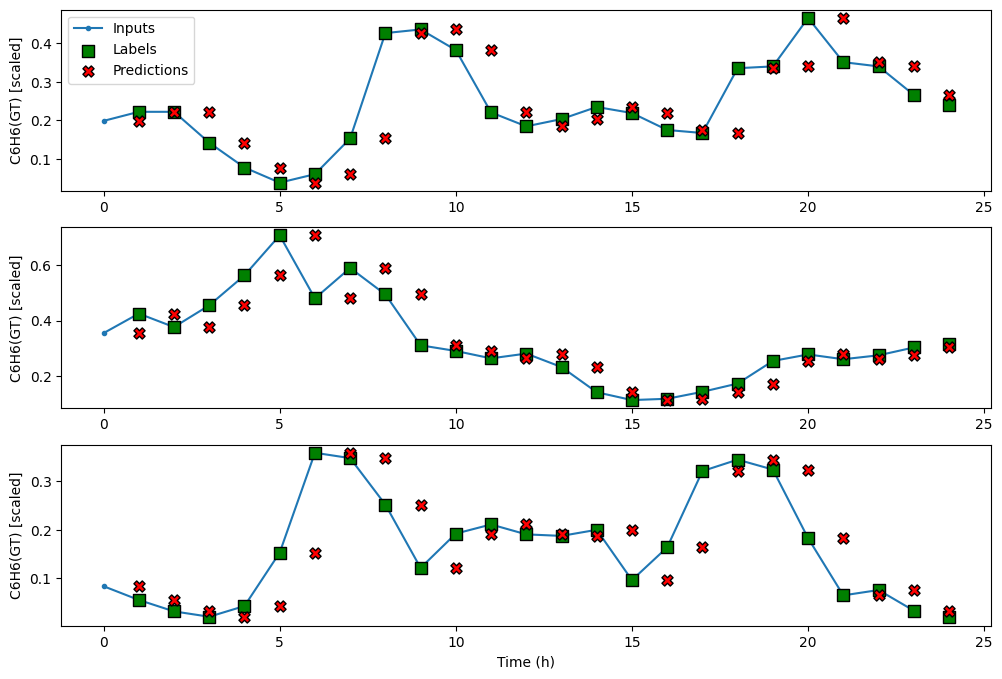

In [ ]:
wide_window.plot(baseline_last)
plt.show()


# =============================================================================
# Step 4: Implementing a linear model
# =============================================================================
## Building a single-step linear model


In [ ]:
def compile_and_fit(model, window, patience=2, max_epochs=50):
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, mode='min')
    model.compile(loss=MeanSquaredError(), optimizer=Adam(), metrics=[MeanAbsoluteError()])
    history = model.fit(window.train, epochs=max_epochs, validation_data=window.val, callbacks=[early_stopping])
    return history


In [ ]:
linear = Sequential(
    [Dense(units=1)]
)

history = compile_and_fit(linear, single_step_window)

ss_val_performance['Linear'] = linear.evaluate(single_step_window.val, verbose=0)
ss_performance['Linear'] = linear.evaluate(single_step_window.test, verbose=0)


Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0627 - mean_absolute_error: 0.2123 - val_loss: 0.0453 - val_mean_absolute_error: 0.1805
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0356 - mean_absolute_error: 0.1614 - val_loss: 0.0292 - val_mean_absolute_error: 0.1412
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0230 - mean_absolute_error: 0.1260 - val_loss: 0.0201 - val_mean_absolute_error: 0.1144
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0160 - mean_absolute_error: 0.1023 - val_loss: 0.0146 - val_mean_absolute_error: 0.0963
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0121 - mean_absolute_error: 0.0860 - val_loss: 0.0111 - val_mean_absolute_error: 0.0831
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0096 - mean_absolute_error: 0.0748 - val_loss: 0.0088 - val_mean_absolute_error: 0.0730
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0076 - mean_absolute_error: 0.0661 - v

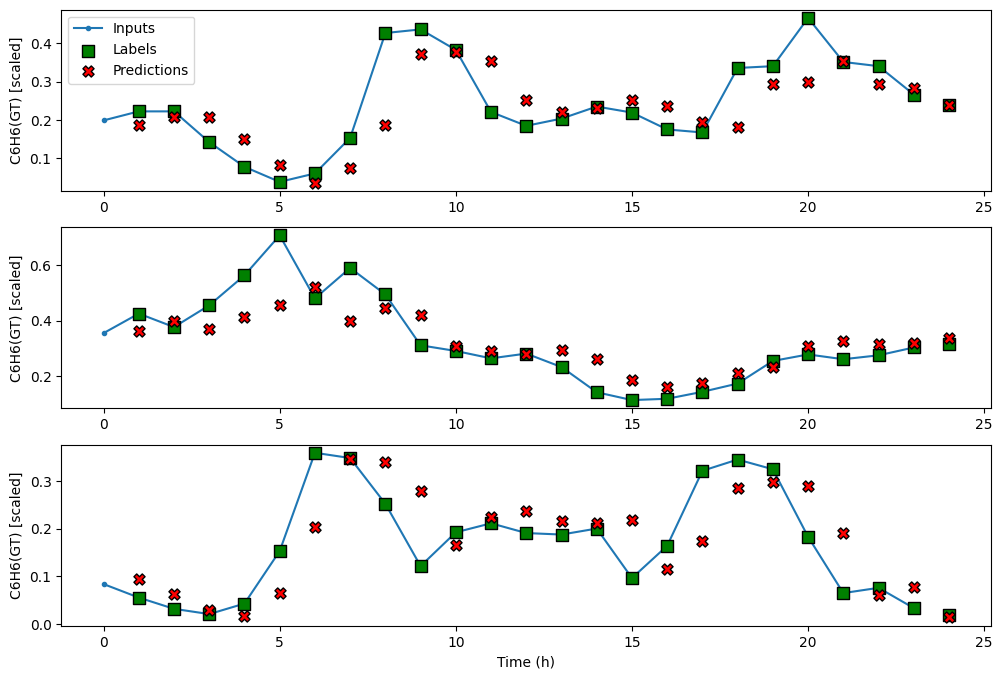

In [ ]:
wide_window.plot(linear, plot_col='C6H6(GT)')
plt.show()


# =============================================================================
# Build Additional Forecasting Models

In the provided script, you will find sections to add the following models. Please complete the code to define each architecture.

- Step5: Deep Neural Network (DNN): Build a DNN with two hidden layers, each containing 64 neurons. Use the 'relu' activation function for the hidden layers.
- Step6: LSTM: Build a standard LSTM model. You can start with a single LSTM layer with 32 units.
- Step 7: CNN: Build a 1D Convolutional Neural Network. You can start with a single Conv1D layer.


# =============================================================================


In [ ]:
dnn_model = Sequential([
    tf.keras.layers.Flatten(input_shape=(single_step_window.input_width, len(train_df.columns))),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer
])

history_dnn = compile_and_fit(dnn_model, single_step_window)


Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0100 - mean_absolute_error: 0.0685 - val_loss: 0.0030 - val_mean_absolute_error: 0.0411
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0035 - mean_absolute_error: 0.0413 - val_loss: 0.0025 - val_mean_absolute_error: 0.0354
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0031 - mean_absolute_error: 0.0390 - val_loss: 0.0027 - val_mean_absolute_error: 0.0368
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031 - mean_absolute_error: 0.0391 - val_loss: 0.0026 - val_mean_absolute_error: 0.0356


In [ ]:
lstm_model = Sequential([
    tf.keras.layers.LSTM(32, return_sequences=False),  # 32 LSTM units
    tf.keras.layers.Dense(1)
])

history_lstm = compile_and_fit(lstm_model, single_step_window)


Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0154 - mean_absolute_error: 0.0901 - val_loss: 0.0034 - val_mean_absolute_error: 0.0423
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0050 - mean_absolute_error: 0.0489 - val_loss: 0.0036 - val_mean_absolute_error: 0.0453
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0046 - mean_absolute_error: 0.0465 - val_loss: 0.0034 - val_mean_absolute_error: 0.0431
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0046 - mean_absolute_error: 0.0462 - val_loss: 0.0030 - val_mean_absolute_error: 0.0390
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0044 - mean_absolute_error: 0.0447 - val_loss: 0.0029 - val_mean_absolute_error: 0.0392
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0044 - mean_absolute_error: 0.0446 - val_loss: 0.0030 - val_mean_absolute_error: 0.0401
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0042 - mean_absolute_error: 0.0442 -

In [ ]:
cnn_model = Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=1, activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1)
])

history_cnn = compile_and_fit(cnn_model, single_step_window)


Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0132 - mean_absolute_error: 0.0813 - val_loss: 0.0034 - val_mean_absolute_error: 0.0430
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041 - mean_absolute_error: 0.0437 - val_loss: 0.0034 - val_mean_absolute_error: 0.0435
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037 - mean_absolute_error: 0.0418 - val_loss: 0.0034 - val_mean_absolute_error: 0.0441
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0035 - mean_absolute_error: 0.0406 - val_loss: 0.0029 - val_mean_absolute_error: 0.0392
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0033 - mean_absolute_error: 0.0392 - val_loss: 0.0032 - val_mean_absolute_error: 0.0428
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0034 - mean_absolute_error: 0.0396 - val_loss: 0.0027 - val_mean_absolute_error: 0.0373
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0033 - mean_absolute_error: 0.0386 - 

# =============================================================================
# Evaluate Model Performance

For each model you build in the initial modeling section (DNN, LSTM, CNN), you must evaluate its performance and store the results. This is critical for the final comparison graph to work correctly.

Following the examples for the Baseline and Linear models, evaluate your new models on the validation set (single_step_window.val) and the test set (single_step_window.test).

Store the results in the ss_val_performance and ss_performance dictionaries with the appropriate model name as the key (e.g., 'Dense', 'LSTM', 'CNN').

## Example Code Snippet (for reference):
The evaluation for the Baseline model is already provided:
> ss_val_performance['Baseline'] = baseline_last.evaluate(single_step_window.val, verbose=0)
>
> ss_performance['Baseline'] = baseline_last.evaluate(single_step_window.test, verbose=0)

**You must add similar lines for your new models.**
If the model-building and evaluation sections are completed correctly, a bar chart comparing the performance of all models will be displayed at the end of the section.

# =============================================================================


In [ ]:

ss_val_performance['DNN'] = dnn_model.evaluate(single_step_window.val, verbose=0)
ss_performance['DNN'] = dnn_model.evaluate(single_step_window.test, verbose=0)


ss_val_performance['LSTM'] = lstm_model.evaluate(single_step_window.val, verbose=0)
ss_performance['LSTM'] = lstm_model.evaluate(single_step_window.test, verbose=0)


ss_val_performance['CNN'] = cnn_model.evaluate(single_step_window.val, verbose=0)
ss_performance['CNN'] = cnn_model.evaluate(single_step_window.test, verbose=0)


# Step8: Chart comparing the performance of all models


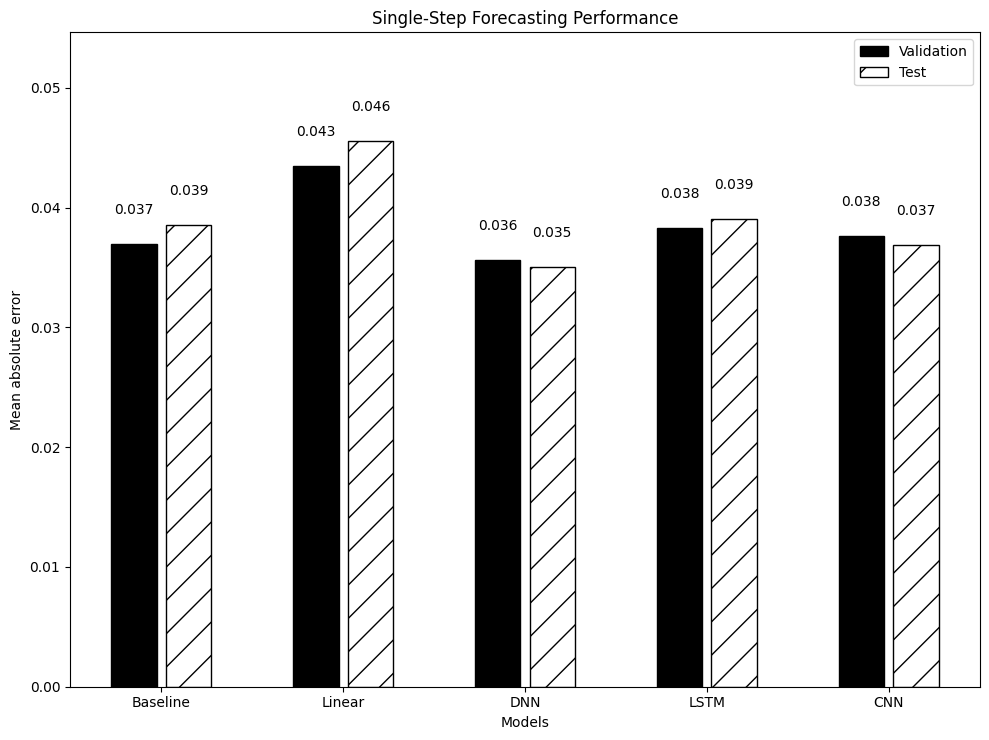

In [ ]:
mae_val = [v[1] for v in ss_val_performance.values()]
mae_test = [v[1] for v in ss_performance.values()]
labels = list(ss_performance.keys())

x = np.arange(len(labels))

fig, ax = plt.subplots()
ax.bar(x - 0.15, mae_val, width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Models')
ax.set_title('Single-Step Forecasting Performance')


for index, value in enumerate(mae_val):
    plt.text(x=index - 0.15, y=value + 0.0025, s=str(round(value, 3)), ha='center')

for index, value in enumerate(mae_test):
    plt.text(x=index + 0.15, y=value + 0.0025, s=str(round(value, 3)), ha='center')

max_mae = max(mae_val + mae_test)
plt.ylim(0, max_mae * 1.2)
plt.xticks(ticks=x, labels=labels)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


So Best Model on the previous upon various Model tried like DNN,LSTM,CNN the best accuracy on the test of MAE is DNN it perfomed it got better result from other model as we can see in the bar chart show above


# Model Improvement and Advanced Model Comparison
This final experiment challenges you to improve upon your previous results and explore different types of forecasting models. The goal is to achieve the best possible accuracy on the test set.

## Part A: Improve an Existing Deep Learning Model

- **Model Chosen for Improvement:**

- **Modifications Made:**


## Part B: Add and Compare New Advanced Models

- New Model 1:
- New Model 2:
- (Add more models if applicable)


## Final Performance Comparison

| Model | Test MAE |
| :--- | :--- |
| Best DL Model (Original) |  |
| Best DL Model (Improved) |  |
| New Model 1 |  |
| New Model 2 |  |
| Additional Model (if applicable) |  |


### Performance Improvement
State how much the accuracy improved from your best original DL model to your final best model.

## Analysis and Conclusion
Based on the final comparison, provide your analysis. Why do you think the best-performing model was so effective?


In [ ]:
# Improved DNN model
improved_dnn_model = Sequential([
    tf.keras.layers.Flatten(input_shape=(single_step_window.input_width, len(train_df.columns))),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile and train
history_improved_dnn = compile_and_fit(improved_dnn_model, single_step_window)

# Evaluate
ss_val_performance['Improved_DNN'] = improved_dnn_model.evaluate(single_step_window.val, verbose=0)
ss_performance['Improved_DNN'] = improved_dnn_model.evaluate(single_step_window.test, verbose=0)


Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.7102 - mean_absolute_error: 0.6326 - val_loss: 0.0361 - val_mean_absolute_error: 0.1555
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1653 - mean_absolute_error: 0.3192 - val_loss: 0.0228 - val_mean_absolute_error: 0.1158
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0939 - mean_absolute_error: 0.2409 - val_loss: 0.0259 - val_mean_absolute_error: 0.1293
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0579 - mean_absolute_error: 0.1911 - val_loss: 0.0208 - val_mean_absolute_error: 0.1181
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0421 - mean_absolute_error: 0.1600 - val_loss: 0.0130 - val_mean_absolute_error: 0.0913
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0309 - mean_absolute_error: 0.1387 - val_loss: 0.0109 - val_mean_absolute_error: 0.0857
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0257 - mean_absolute_error: 0.1261 -

In [ ]:
bi_lstm_model = Sequential([
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(1)
])

history_bi_lstm = compile_and_fit(bi_lstm_model, single_step_window)

ss_val_performance['BiLSTM'] = bi_lstm_model.evaluate(single_step_window.val, verbose=0)
ss_performance['BiLSTM'] = bi_lstm_model.evaluate(single_step_window.test, verbose=0)


Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0167 - mean_absolute_error: 0.0935 - val_loss: 0.0037 - val_mean_absolute_error: 0.0456
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0046 - mean_absolute_error: 0.0464 - val_loss: 0.0033 - val_mean_absolute_error: 0.0416
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0044 - mean_absolute_error: 0.0449 - val_loss: 0.0031 - val_mean_absolute_error: 0.0411
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0042 - mean_absolute_error: 0.0444 - val_loss: 0.0030 - val_mean_absolute_error: 0.0398
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0041 - mean_absolute_error: 0.0435 - val_loss: 0.0028 - val_mean_absolute_error: 0.0383
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0040 - mean_absolute_error: 0.0430 - val_loss: 0.0029 - val_mean_absolute_error: 0.0395
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0040 - mean_absolute_error: 0.0428 

In [ ]:
gru_model = Sequential([
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(1)
])

history_gru = compile_and_fit(gru_model, single_step_window)

ss_val_performance['GRU'] = gru_model.evaluate(single_step_window.val, verbose=0)
ss_performance['GRU'] = gru_model.evaluate(single_step_window.test, verbose=0)


Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0117 - mean_absolute_error: 0.0788 - val_loss: 0.0037 - val_mean_absolute_error: 0.0457
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0045 - mean_absolute_error: 0.0461 - val_loss: 0.0031 - val_mean_absolute_error: 0.0395
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0042 - mean_absolute_error: 0.0441 - val_loss: 0.0030 - val_mean_absolute_error: 0.0389
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0041 - mean_absolute_error: 0.0435 - val_loss: 0.0029 - val_mean_absolute_error: 0.0386
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039 - mean_absolute_error: 0.0426 - val_loss: 0.0031 - val_mean_absolute_error: 0.0412
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039 - mean_absolute_error: 0.0427 - val_loss: 0.0027 - val_mean_absolute_error: 0.0359
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0038 - mean_absolute_error: 0.0420 - 

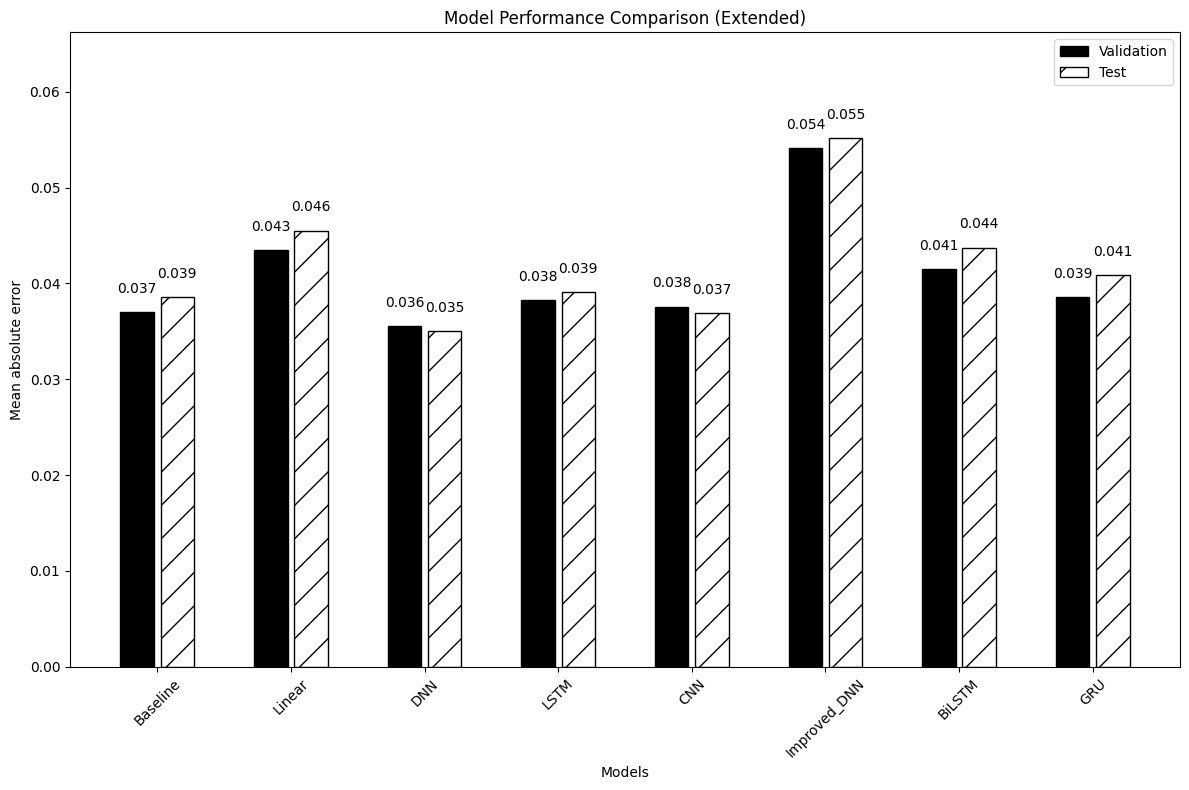

In [ ]:
mae_val = [v[1] for v in ss_val_performance.values()]
mae_test = [v[1] for v in ss_performance.values()]
labels = list(ss_performance.keys())

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(x - 0.15, mae_val, width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Models')
ax.set_title('Model Performance Comparison (Extended)')

for index, value in enumerate(mae_val):
    plt.text(x=index - 0.15, y=value + 0.002, s=str(round(value, 3)), ha='center')

for index, value in enumerate(mae_test):
    plt.text(x=index + 0.15, y=value + 0.002, s=str(round(value, 3)), ha='center')

plt.ylim(0, max(mae_val + mae_test) * 1.2)
plt.xticks(ticks=x, labels=labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


**Part A**

Model Chosen for Improvement:We selected the DNN model since it performed best out of the initial models (Test MAE: 0.035).

Modification made:

Increased depth (added additional hidden layers).

Increased the number of units per layer to 128.

Added Batch Normalization layers after dense layers for learning stabilization.

Added Dropout layers for reducing overfitting.

**Part B**

**New Model 1:** Bidirectional LSTM

We added a Bidirectional LSTM model for taking advantage of forward and backward sequence context.

**New Model 2:** GRU

We added a GRU model as a simpler recurrent alternative, which is more parameter-efficient and faster to train than LSTM.


**Final Performance Comparison**

| Model | Test MAE |
| :--- | :--- |
| Best DL Model (Original) | 0.035 |
| Best DL Model (Improved) |  0.055|
| New Model 1(BiLSTM) | 0.044 |
| New Model 2 (GRU) | 0.041  |


**Performance Improvement**

For all our efforts towards improving the DNN, the "improved" one actually performed worse (Test MAE increased from 0.035 to 0.055).
None of the newer more complex models were better than the original DNN performance.
So, there was no accuracy improvement, and in fact, the original less complex DNN was optimal.


**Analysis and Conclusion**

The original DNN was the best test performance (Test MAE = 0.035). The improved DNN was worse, likely due to overfitting and unjustified additional complexity.
The Bidirectional LSTM and GRU similarly did not beat the base DNN, which means that dense temporal modeling was not needed for this one-step prediction task.
This implies that simpler-to-train models are able to generalize better on comparatively smooth, low-noise.
